In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [37]:
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")

transactions = pd.read_csv("../data/processed/clean_transactions.csv")

portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

# Mutual Fund Analytics

## Exploratory Data Analysis

Bluestock Fintech Capstone

Day 3

In [38]:
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

# ADD THESE TWO LINES
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']


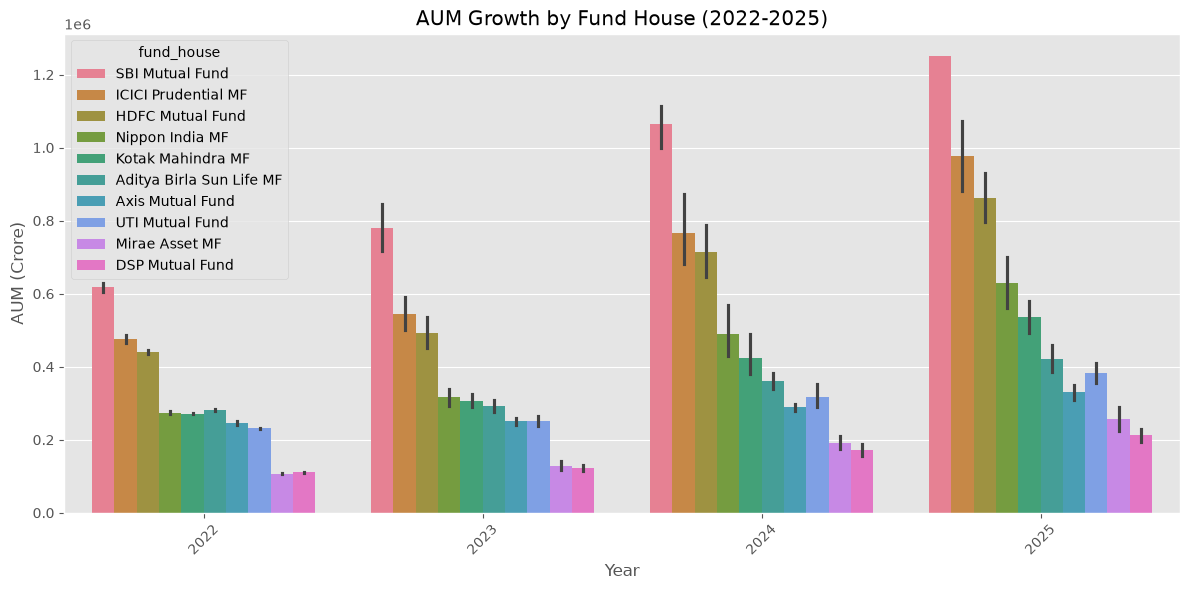

In [82]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../charts/aum_growth.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [40]:
print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


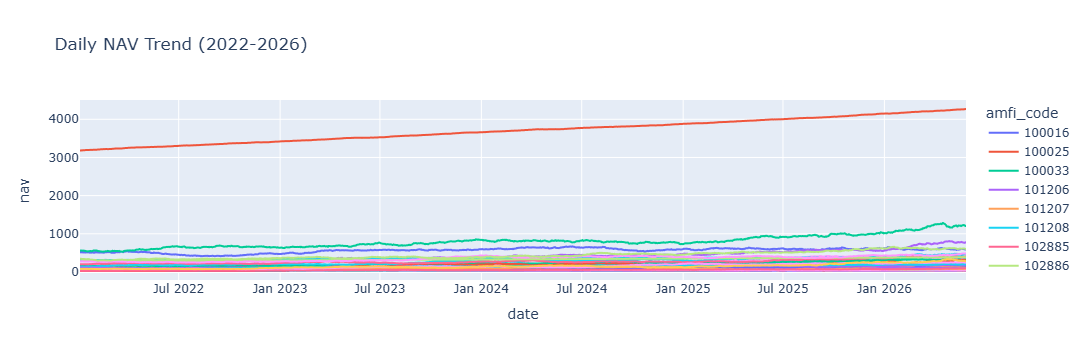

In [41]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

fig.write_image("../charts/nav_trend.png")

### Insight

NAV values steadily increased during 2023 indicating a strong bull market.

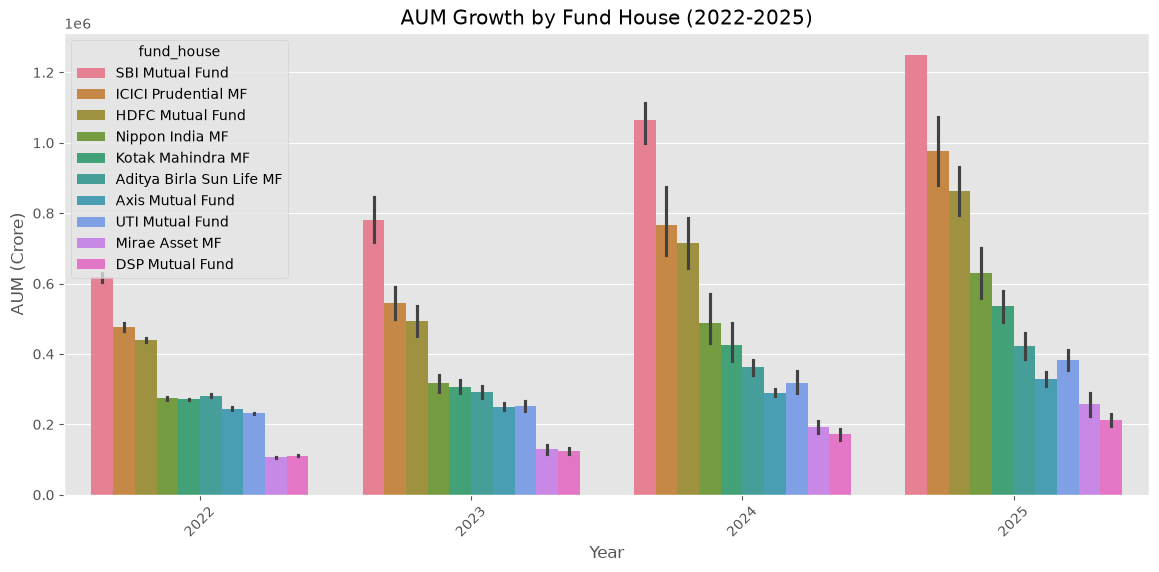

In [42]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Create the chart
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.show()

# Uncomment after installing Kaleido / when exporting
# plt.savefig("../charts/aum_growth.png", dpi=300, bbox_inches="tight")

In [43]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']


### Insight

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore during the analysis period.

In [44]:
print("fund")
print(fund.columns.tolist())

print("\nnav")
print(nav.columns.tolist())

print("\naum")
print(aum.columns.tolist())

print("\nsip")
print(sip.columns.tolist())

print("\ncategory")
print(category.columns.tolist())

print("\nfolio")
print(folio.columns.tolist())

print("\ntransactions")
print(transactions.columns.tolist())

print("\nportfolio")
print(portfolio.columns.tolist())

fund
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

nav
['amfi_code', 'date', 'nav']

aum
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']

sip
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

category
['month', 'category', 'net_inflow_crore']

folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfol

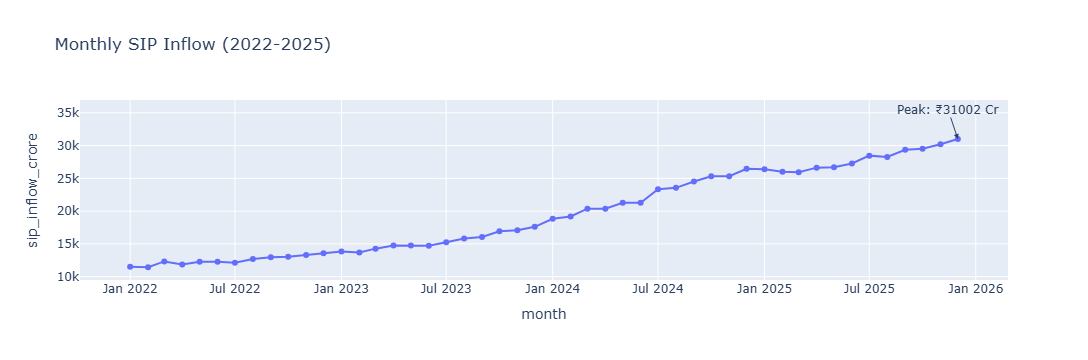

In [45]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (2022-2025)",
    markers=True
)

# Highlight maximum SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

# fig.write_image("../charts/sip_trend.png")

### Insight

Monthly SIP inflows steadily increased over time and reached their highest level at the end of the dataset.

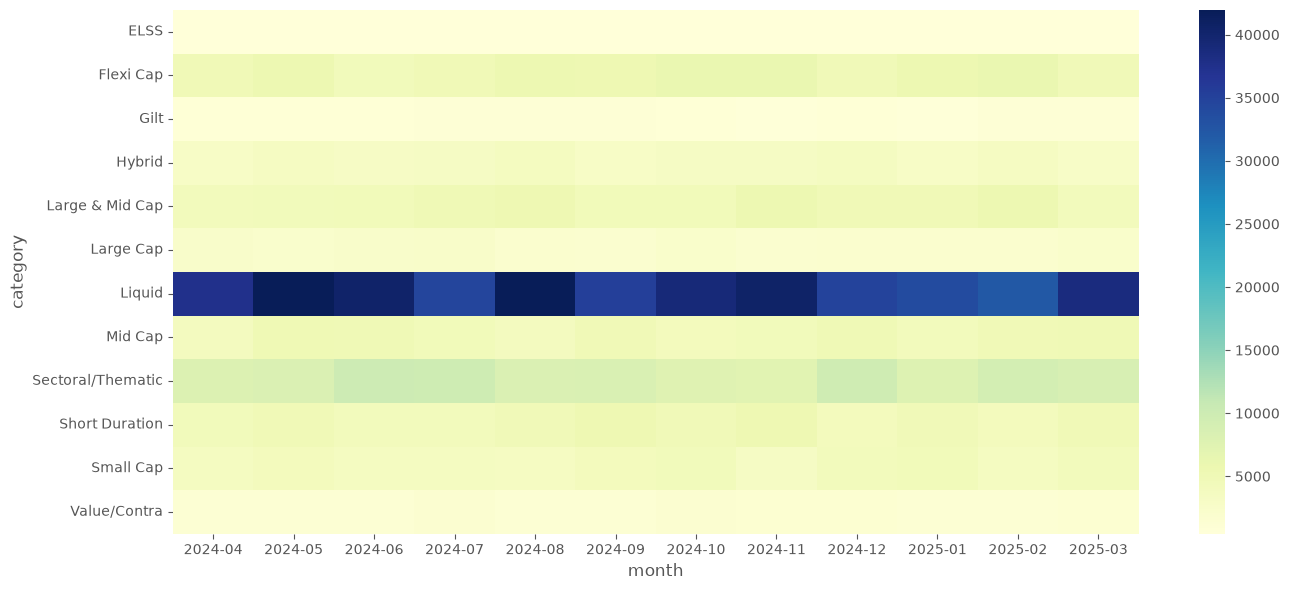

In [83]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=False
)

plt.tight_layout()
plt.savefig("../charts/category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Insight

Large-cap and diversified equity categories consistently attracted higher inflows than other categories.

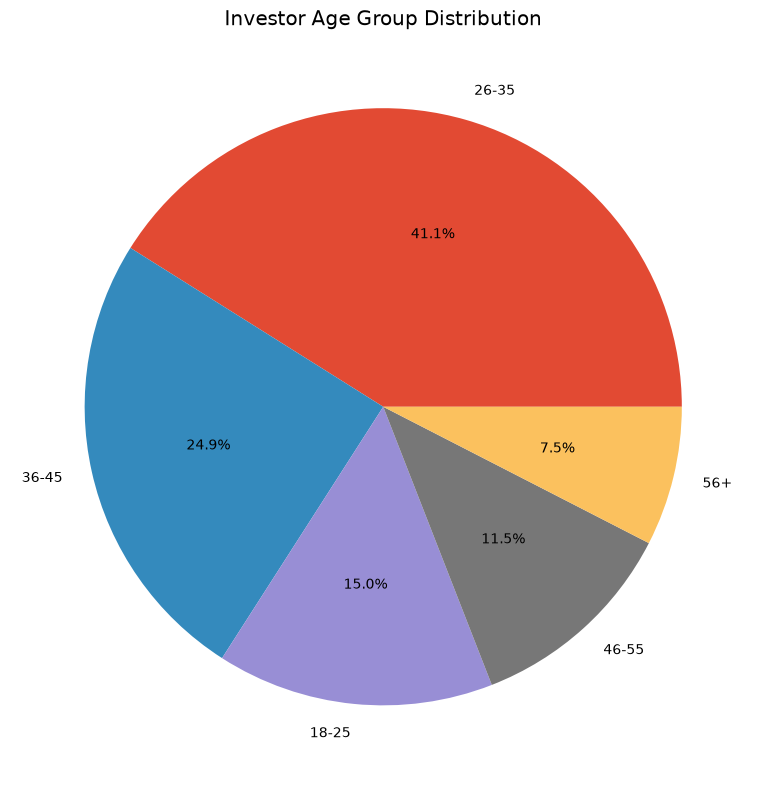

In [84]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.tight_layout()
plt.savefig("../charts/age_group_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

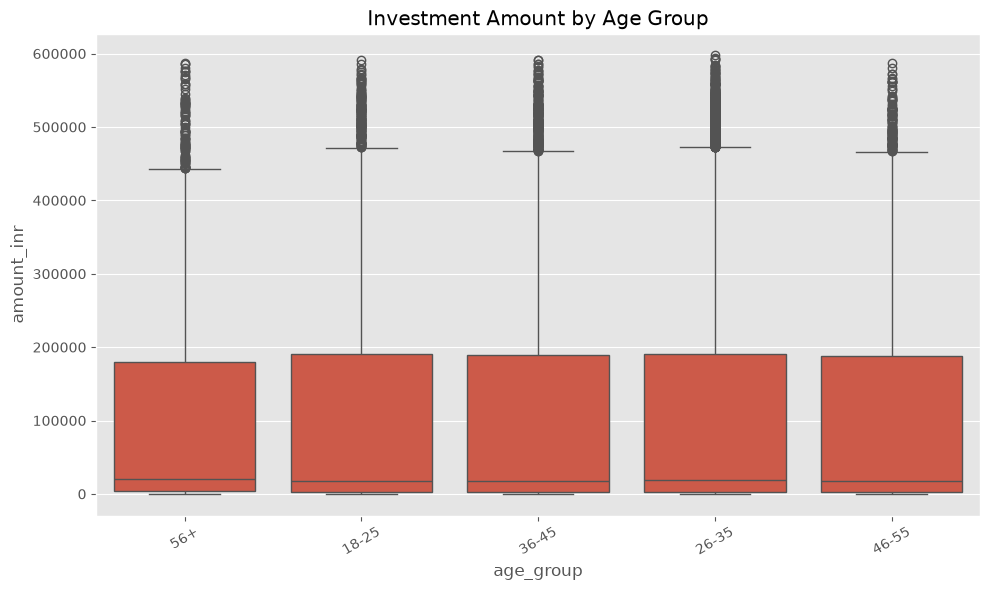

In [85]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../charts/amount_by_age.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Insight

Middle-aged investors contribute higher investment amounts than younger investors.

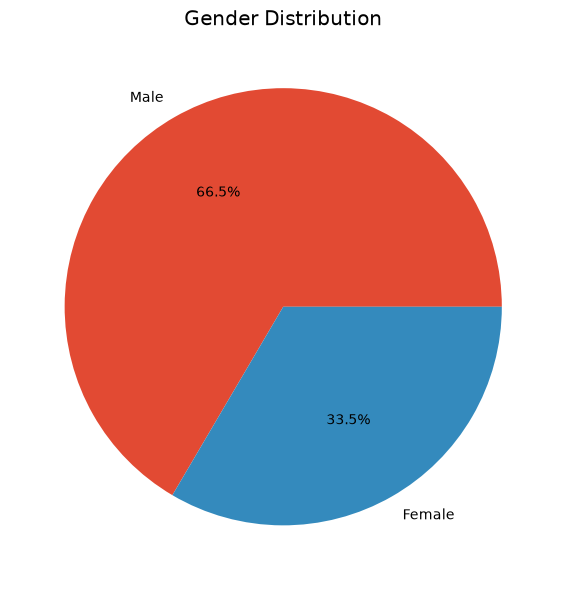

In [86]:
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.tight_layout()
plt.savefig("../charts/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

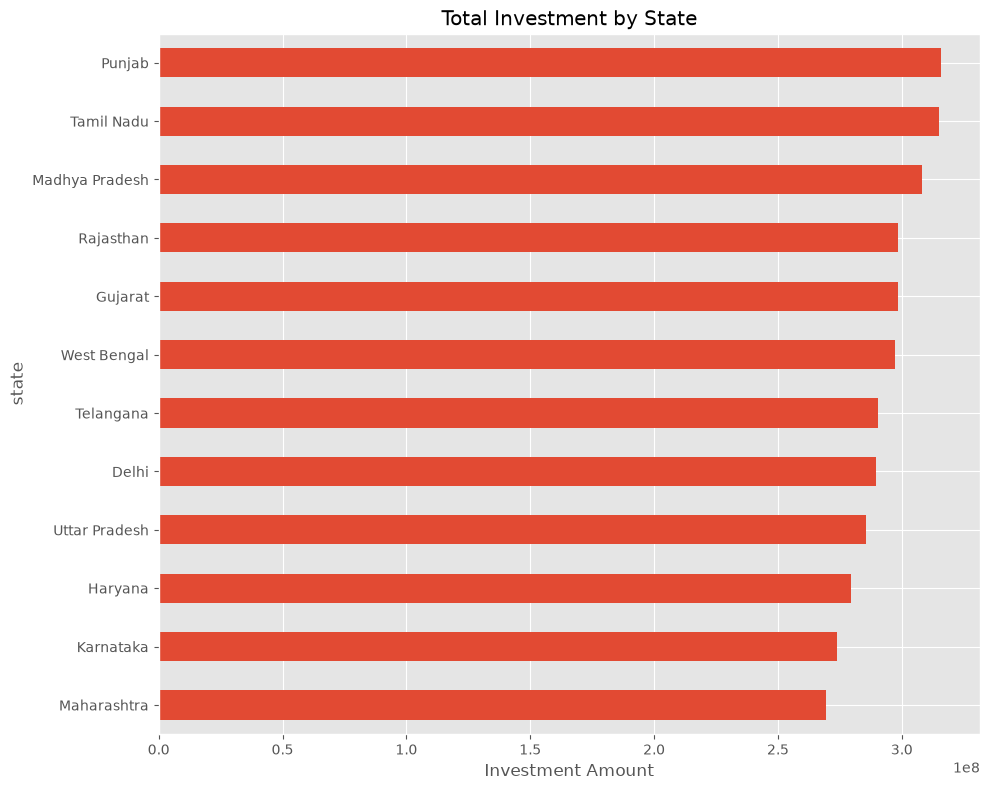

In [87]:
state = transactions.groupby("state")["amount_inr"].sum()

state = state.sort_values()

plt.figure(figsize=(10,8))

state.plot(kind="barh")

plt.title("Total Investment by State")

plt.xlabel("Investment Amount")

plt.tight_layout()
plt.savefig("../charts/state_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Insight

A few major states contribute a significant share of the total investment volume.

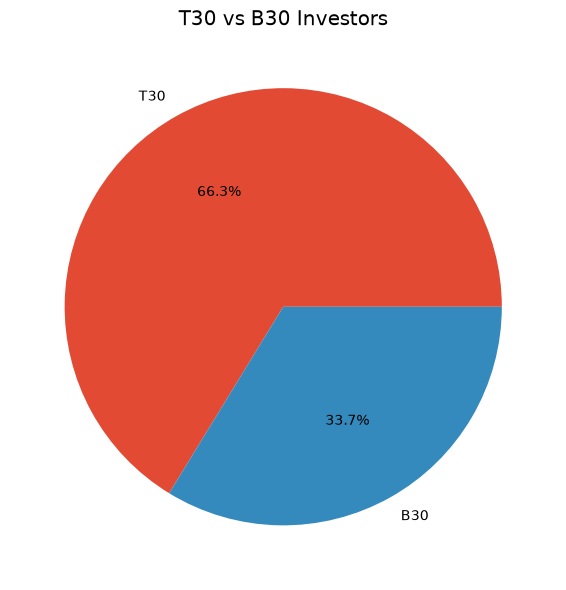

In [88]:
plt.figure(figsize=(6,6))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.ylabel("")

plt.tight_layout()
plt.savefig("../charts/city_tier.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

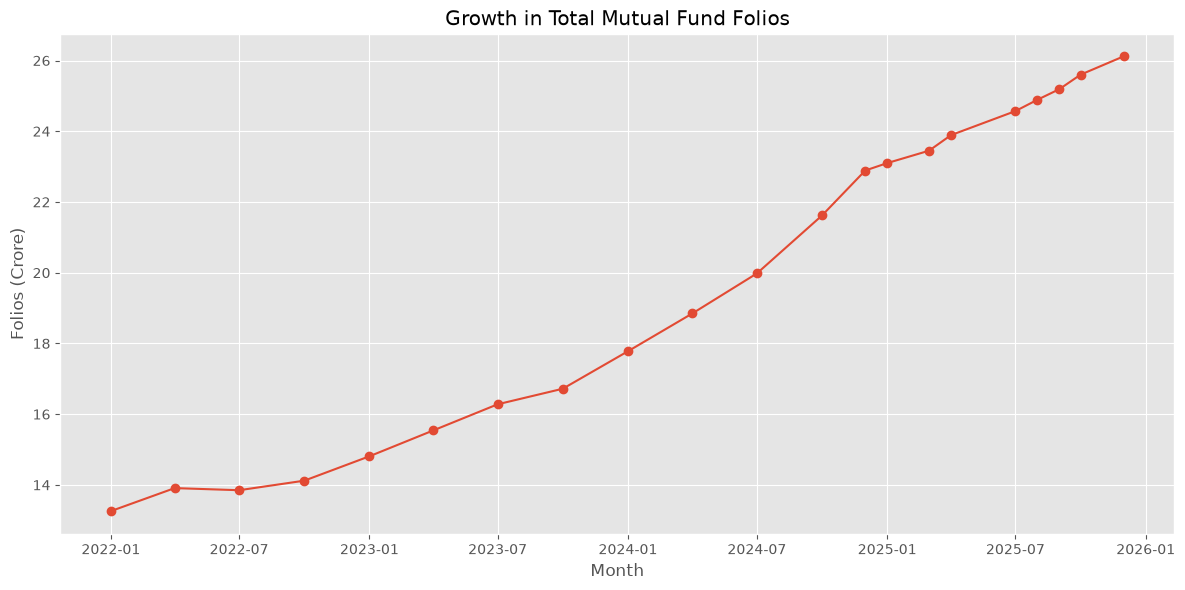

In [89]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Total Mutual Fund Folios")

plt.xlabel("Month")

plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.tight_layout()
plt.savefig("../charts/folio_growth.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Insight

The number of mutual fund folios increased consistently throughout the analysis period.

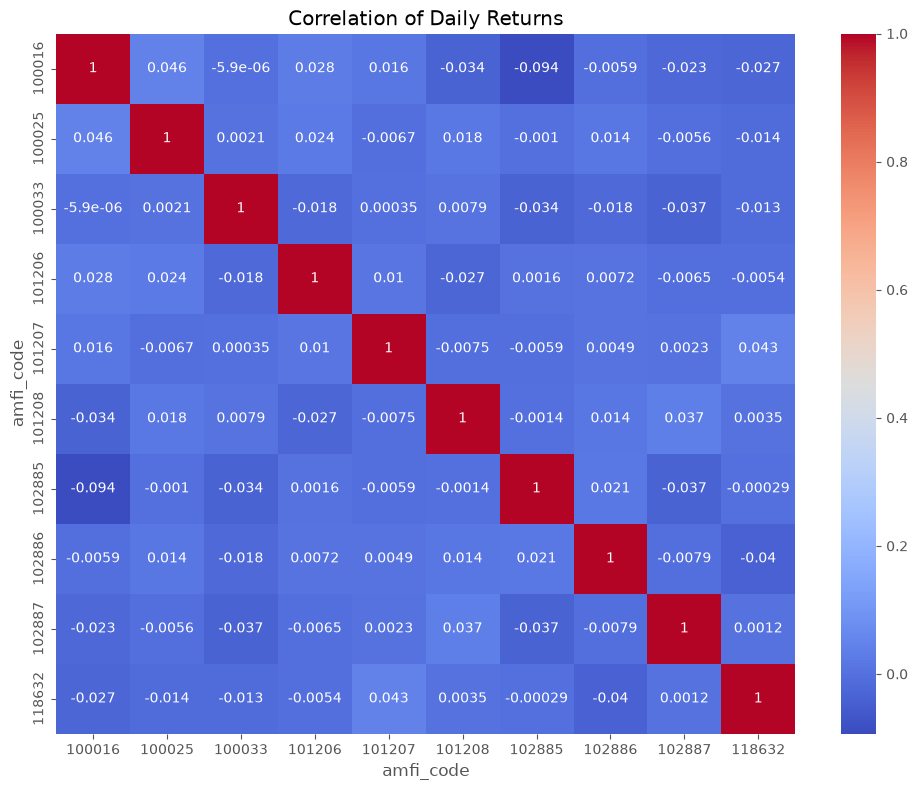

In [90]:
returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = returns.pct_change()

# Select first 10 funds
returns = returns.iloc[:, :10]

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation of Daily Returns")
plt.tight_layout()
plt.savefig("../charts/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

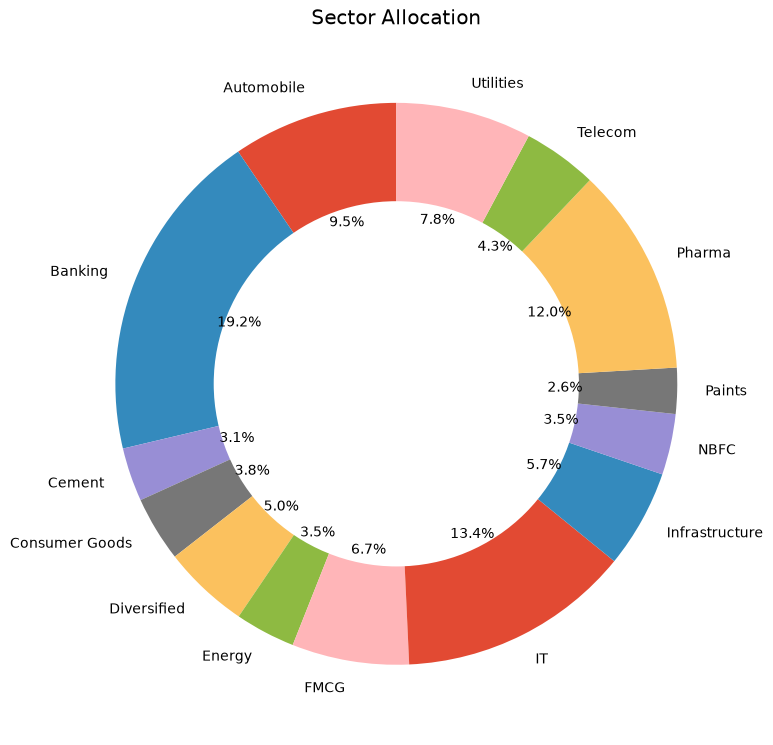

In [91]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90
)

centre = plt.Circle((0,0),0.65,fc="white")

plt.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.tight_layout()
plt.savefig("../charts/sector_allocation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Insight

Financial and technology sectors account for a significant share of portfolio allocations.

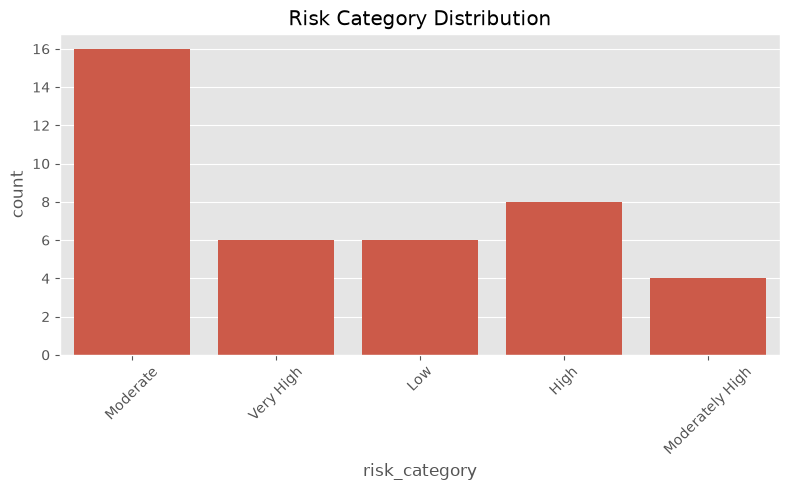

In [92]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund,
    x="risk_category"
)

plt.xticks(rotation=45)

plt.title("Risk Category Distribution")

plt.tight_layout()
plt.savefig("../charts/risk_category.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

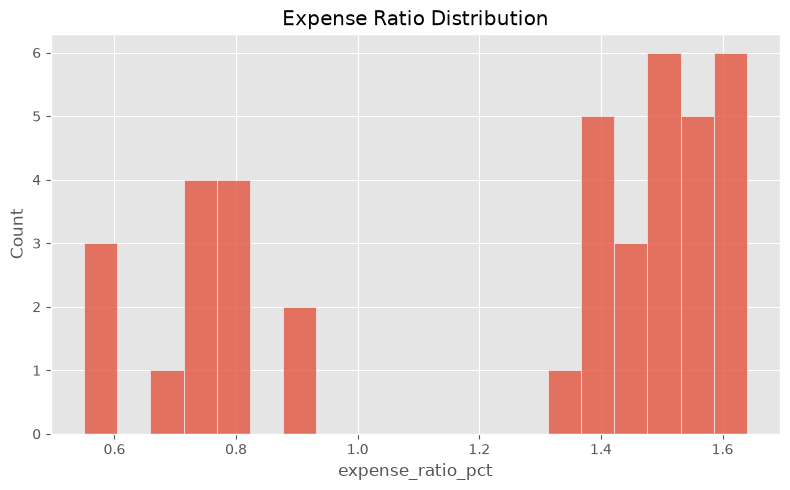

In [93]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund["expense_ratio_pct"],
    bins=20
)

plt.title("Expense Ratio Distribution")

plt.tight_layout()
plt.savefig("../charts/expense_ratio_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

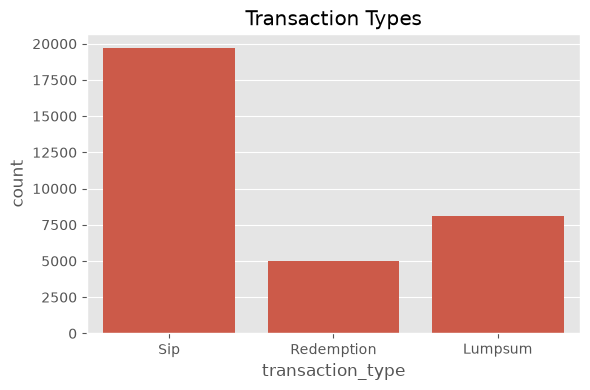

In [94]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Types")

plt.tight_layout()
plt.savefig("../charts/transaction_type.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

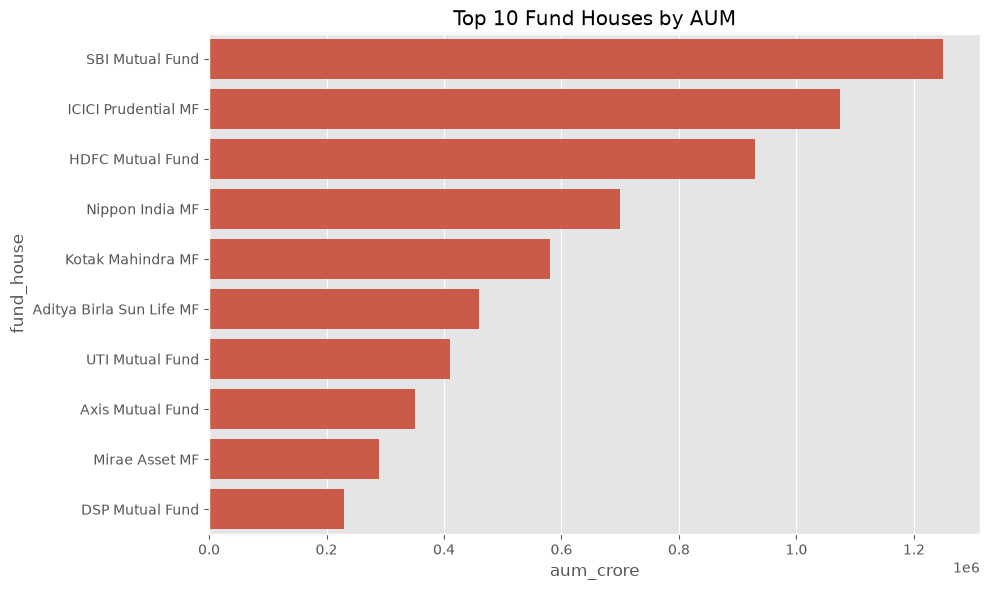

In [95]:
latest = aum.sort_values("date").groupby("fund_house").tail(1)

top = latest.sort_values("aum_crore", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top 10 Fund Houses by AUM")

plt.tight_layout()
plt.savefig("../charts/top10_fund_house.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

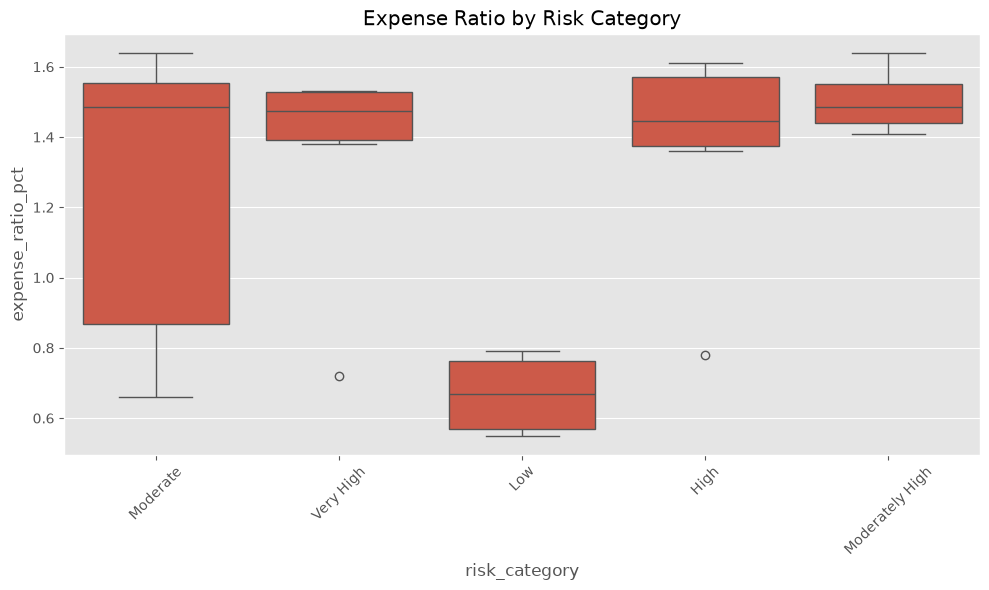

In [96]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=fund,
    x="risk_category",
    y="expense_ratio_pct"
)

plt.xticks(rotation=45)

plt.title("Expense Ratio by Risk Category")


plt.tight_layout()
plt.savefig("../charts/expense_ratio_by_risk_category.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Key EDA Findings

1. NAV values showed an overall upward trend during the analysis period.
2. SBI Mutual Fund maintained one of the highest AUM values.
3. SIP inflows steadily increased and peaked at the end of the dataset.
4. Equity-oriented categories received higher net inflows.
5. Most investors belonged to the middle-age groups.
6. Investment amounts varied significantly across age groups.
7. A few states accounted for the majority of investments.
8. T30 cities contributed a larger share of investors than B30 cities.
9. Mutual fund folio counts increased consistently over time.
10. Portfolio allocations were concentrated in a few major sectors.

In [60]:
plt.savefig("../charts/aum_growth.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>

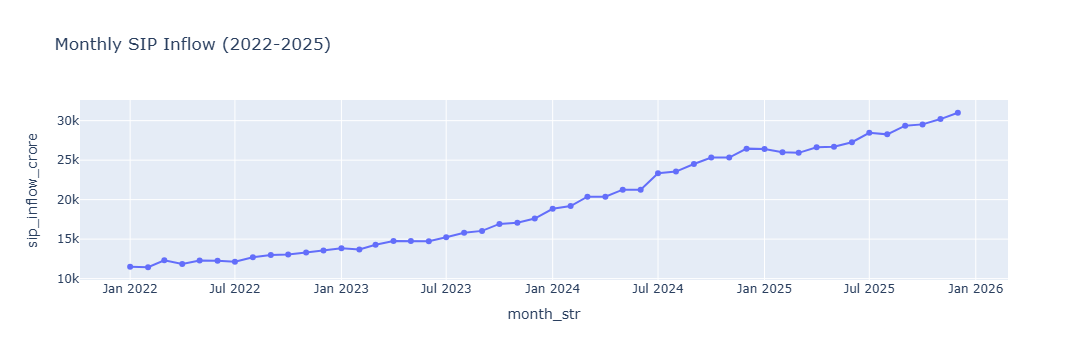

In [62]:
sip_plot = sip.copy()

sip_plot["month"] = pd.to_datetime(sip_plot["month"])
sip_plot["month_str"] = sip_plot["month"].dt.strftime("%Y-%m")

fig = px.line(
    sip_plot,
    x="month_str",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (2022-2025)",
    markers=True
)

fig.write_image("../charts/sip_trend.png")
fig.show()

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")

plt.tight_layout()

plt.savefig("../charts/aum_growth.png", dpi=300)

plt.show()